# nanoGPT Ablation Study
Depth & head ablation on FineWeb-Edu. Kaggle P100 GPU.

**Setup:** Upload `model.py`, `train.py`, `generate.py`, `data/prepare.py` as a Kaggle Dataset, then attach it here.

In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/nilsleutenegger/programme/train.py
/kaggle/input/datasets/nilsleutenegger/programme/prepare.py
/kaggle/input/datasets/nilsleutenegger/programme/model.py
/kaggle/input/datasets/nilsleutenegger/programme/generate.py


In [4]:
# Cell 1 -- Check GPU
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")


GPU: Tesla T4
VRAM: 15.6 GB
CUDA: 12.8
PyTorch: 2.10.0+cu128


In [5]:
# Cell 2 -- Install dependencies
!pip install tiktoken datasets -q


In [6]:
# Cell 3 -- Copy project files from Kaggle input dataset
# After attaching your dataset, files are at /kaggle/input/<dataset-name>/
import os, shutil, glob

os.makedirs("/kaggle/working/data",        exist_ok=True)
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/ablation",    exist_ok=True)
os.chdir("/kaggle/working")

# Find the attached dataset (adjust dataset name if needed)
input_dirs = glob.glob("/kaggle/input/*/")
print("Available input datasets:", input_dirs)

if input_dirs:
    src = input_dirs[0].rstrip("/")
    for f in ["model.py", "train.py", "generate.py"]:
        src_path = f"{src}/{f}"
        if os.path.exists(src_path):
            shutil.copy(src_path, f"/kaggle/working/{f}")
            print(f"  Copied: {f}")
    for f in ["prepare.py"]:
        src_path = f"{src}/data/{f}"
        if not os.path.exists(src_path):
            src_path = f"{src}/{f}"
        if os.path.exists(src_path):
            shutil.copy(src_path, f"/kaggle/working/data/{f}")
            print(f"  Copied: data/{f}")
else:
    print("No dataset attached. Upload files manually below.")
    # Manual fallback
    from kaggle_secrets import UserSecretsClient


Available input datasets: ['/kaggle/input/datasets/']


In [7]:
import os, shutil

os.makedirs("/kaggle/working/data", exist_ok=True)
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/ablation", exist_ok=True)
os.chdir("/kaggle/working")

src = "/kaggle/input/datasets/nilsleutenegger/programme"

for f in ["model.py", "train.py", "generate.py"]:
    shutil.copy(f"{src}/{f}", f"/kaggle/working/{f}")
    print(f"Copied: {f}")

shutil.copy(f"{src}/prepare.py", "/kaggle/working/data/prepare.py")
print("Copied: data/prepare.py")

print("\nFiles:")
os.system("find /kaggle/working -name '*.py' | sort")

Copied: model.py
Copied: train.py
Copied: generate.py
Copied: data/prepare.py

Files:
/kaggle/working/data/prepare.py
/kaggle/working/generate.py
/kaggle/working/model.py
/kaggle/working/train.py


0

In [8]:
# Cell 4 -- Prepare data (~3 min on P100)
import os
os.chdir("/kaggle/working")
!python data/prepare.py --source=fineweb --fineweb_docs=100000


Loading GPT-2 tokenizer (gpt2)...
  vocab_size=50257, eot_token=50256
README.md: 26.4kB [00:00, 53.5MB/s]
Resolving data files: 100%|██████████████| 2410/2410 [00:00<00:00, 25247.96it/s]
  10,000 / 100,000
  20,000 / 100,000
  30,000 / 100,000
  40,000 / 100,000
  50,000 / 100,000
  60,000 / 100,000
  70,000 / 100,000
  80,000 / 100,000
  90,000 / 100,000
  100,000 / 100,000
Tokenising...

Saving binary files (source=fineweb)...
  train.bin: 103,979,506 tokens  (208.0 MB)
  val.bin: 523,410 tokens  (1.0 MB)

Fertig.
  Train: 103,979,506 tokens
  Val:   523,410 tokens

Naechster Schritt: python train.py


In [9]:
# Cell 5 -- Verify data
import json
with open("data/meta.json") as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

import os
for fname in ["data/train.bin", "data/val.bin"]:
    size = os.path.getsize(fname) / 1e6
    print(f"{fname}: {size:.1f} MB")


{
  "source": "fineweb",
  "vocab_size": 50257,
  "vocab_size_padded": 50304,
  "train_tokens": 103979506,
  "val_tokens": 523410,
  "encoding": "gpt2"
}
data/train.bin: 208.0 MB
data/val.bin: 1.0 MB


In [10]:
# Cell 6 -- Baseline: 6L 6H (~8 min on P100)
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.chdir("/kaggle/working")

!python train.py --n_layer=6 --n_head=6 --n_embd=384 --block_size=256 --batch_size=32 --max_iters=5000 --eval_interval=500 --run_name=baseline


Device: cuda  dtype: torch.bfloat16
Model: 6L 6H 384d  Parameters: 30.06M

Training for 5000 iterations...
  iter   train_loss    val_loss         lr   ms/iter
-------------------------------------------------------
     0      10.9245     10.9265   0.00e+00     65.4
   500       6.3851      6.4713   2.97e-04    824.6
  1000       5.9475      6.0542   2.82e-04    832.9
  1500       5.7072      5.8240   2.54e-04    833.2
  2000       5.5549      5.6661   2.17e-04    833.3
  2500       5.4320      5.5528   1.74e-04    833.2
  3000       5.3131      5.4454   1.30e-04    833.6
  3500       5.2928      5.3939   9.00e-05    833.5
  4000       5.2299      5.3493   5.79e-05    833.5
  4500       5.1877      5.3294   3.72e-05    834.0
  5000       5.1748      5.2975   3.00e-05    834.0

Done. Best val loss: 5.2975
Checkpoint: checkpoints/baseline/ckpt.pt


In [11]:
# Cell 7 -- Depth ablation: n_layer in 2,4,8  (n_head=6 fixed, ~25 min total)
import os, subprocess, sys
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.chdir("/kaggle/working")

for n_layer in [2, 4, 8]:
    print(f"\n==================================================")
    print(f"Running: L{n_layer}_H6")
    print(f"==================================================\n")
    result = subprocess.run([
        sys.executable, "train.py",
        f"--n_layer={n_layer}", "--n_head=6", "--n_embd=384",
        "--block_size=256", f"--batch_size=32",
        "--max_iters=5000", "--eval_interval=500",
        f"--run_name=L{n_layer}_H6",
    ])
    if result.returncode != 0:
        print(f"WARNING: run failed with code {result.returncode}")
print("\nDepth ablation complete.")



Running: L2_H6

Device: cuda  dtype: torch.bfloat16
Model: 2L 6H 384d  Parameters: 22.96M

Training for 5000 iterations...
  iter   train_loss    val_loss         lr   ms/iter
-------------------------------------------------------
     0      10.9076     10.9100   0.00e+00     52.9
   500       6.3985      6.4714   2.97e-04    622.0
  1000       6.0126      6.1124   2.82e-04    625.2
  1500       5.8173      5.9388   2.54e-04    624.7
  2000       5.6805      5.8036   2.17e-04    625.4
  2500       5.5781      5.6924   1.74e-04    626.0
  3000       5.5025      5.6266   1.30e-04    625.7
  3500       5.4351      5.5713   9.00e-05    626.8
  4000       5.4008      5.5357   5.79e-05    626.5
  4500       5.3880      5.5099   3.72e-05    626.7
  5000       5.3673      5.4891   3.00e-05    627.0

Done. Best val loss: 5.4891
Checkpoint: checkpoints/L2_H6/ckpt.pt


Error: ['<', 'D', 'i', 'r', 'E', 'n', 't', 'r', 'y', ' ', "'", 'l', 'o', 'g', '.', 'j', 's', 'o', 'n', "'", '>', ' ', 'a', 'n', 'd', ' ', "'", '/', 'k', 'a', 'g', 'g', 'l', 'e', '/', 'w', 'o', 'r', 'k', 'i', 'n', 'g', '/', 'c', 'h', 'e', 'c', 'k', 'p', 'o', 'i', 'n', 't', 's', '/', 'L', '2', '_', 'H', '6', '/', 'l', 'o', 'g', '.', 'j', 's', 'o', 'n', "'", ' ', 'a', 'r', 'e', ' ', 't', 'h', 'e', ' ', 's', 'a', 'm', 'e', ' ', 'f', 'i', 'l', 'e', '<', 'D', 'i', 'r', 'E', 'n', 't', 'r', 'y', ' ', "'", 'c', 'k', 'p', 't', '.', 'p', 't', "'", '>', ' ', 'a', 'n', 'd', ' ', "'", '/', 'k', 'a', 'g', 'g', 'l', 'e', '/', 'w', 'o', 'r', 'k', 'i', 'n', 'g', '/', 'c', 'h', 'e', 'c', 'k', 'p', 'o', 'i', 'n', 't', 's', '/', 'L', '2', '_', 'H', '6', '/', 'c', 'k', 'p', 't', '.', 'p', 't', "'", ' ', 'a', 'r', 'e', ' ', 't', 'h', 'e', ' ', 's', 'a', 'm', 'e', ' ', 'f', 'i', 'l', 'e', '<', 'D', 'i', 'r', 'E', 'n', 't', 'r', 'y', ' ', "'", 'c', 'o', 'n', 'f', 'i', 'g', '.', 'j', 's', 'o', 'n', "'", '>', ' 

In [12]:
# Cell 8 -- Head ablation: n_head in 1,2,3  (n_layer=6 fixed, ~25 min total)
import os, subprocess, sys
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.chdir("/kaggle/working")

for n_head in [1, 2, 3]:
    print(f"\n==================================================")
    print(f"Running: L6_H{n_head}")
    print(f"==================================================\n")
    result = subprocess.run([
        sys.executable, "train.py",
        "--n_layer=6", f"--n_head={n_head}", "--n_embd=384",
        "--block_size=256", f"--batch_size=32",
        "--max_iters=5000", "--eval_interval=500",
        f"--run_name=L6_H{n_head}",
    ])
    if result.returncode != 0:
        print(f"WARNING: run failed with code {result.returncode}")

print("\nHead ablation complete.")



Running: L6_H1

Device: cuda  dtype: torch.bfloat16
Model: 6L 1H 384d  Parameters: 30.06M

Training for 5000 iterations...
  iter   train_loss    val_loss         lr   ms/iter
-------------------------------------------------------
     0      10.8835     10.8846   0.00e+00     61.2
   500       6.3804      6.4797   2.97e-04    788.4
  1000       5.9745      6.0766   2.82e-04    797.1
  1500       5.7533      5.8522   2.54e-04    797.4
  2000       5.5826      5.6900   2.17e-04    797.9
  2500       5.4881      5.5858   1.74e-04    797.6
  3000       5.3698      5.4886   1.30e-04    798.3
  3500       5.3186      5.4199   9.00e-05    798.9
  4000       5.2681      5.3721   5.79e-05    798.6
  4500       5.2323      5.3487   3.72e-05    798.3
  5000       5.2076      5.3385   3.00e-05    797.8

Done. Best val loss: 5.3385
Checkpoint: checkpoints/L6_H1/ckpt.pt

Running: L6_H2

Device: cuda  dtype: torch.bfloat16
Model: 6L 2H 384d  Parameters: 30.06M

Training for 5000 iterations...
  it

In [13]:
# Cell 9 -- Collect results
import os, json
import numpy as np

os.chdir("/kaggle/working")
ckpt_dir = "checkpoints"
results = []

for run_name in sorted(os.listdir(ckpt_dir)):
    log_path = f"{ckpt_dir}/{run_name}/log.json"
    cfg_path = f"{ckpt_dir}/{run_name}/config.json"
    if not os.path.exists(log_path) or not os.path.exists(cfg_path):
        continue
    with open(log_path) as f:
        log = json.load(f)
    with open(cfg_path) as f:
        cfg = json.load(f)
    best_val  = min(r["val"] for r in log)
    final_val = log[-1]["val"]
    results.append({
        "run":        run_name,
        "n_layer":    cfg["n_layer"],
        "n_head":     cfg["n_head"],
        "best_val":   round(best_val,  4),
        "final_val":  round(final_val, 4),
        "perplexity": round(float(np.exp(best_val)), 2),
    })

results.sort(key=lambda r: r["best_val"])
print(f"{'Run':>12}  {'L':>3}  {'H':>3}  {'best_val':>9}  {'PPL':>8}")
print("-" * 45)
for r in results:
    print(f"{r['run']:>12}  {r['n_layer']:>3}  {r['n_head']:>3}  "
          f"{r['best_val']:>9.4f}  {r['perplexity']:>8.2f}")

os.makedirs("ablation", exist_ok=True)
with open("ablation/results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved: ablation/results.json")


         Run    L    H   best_val       PPL
---------------------------------------------
    baseline    6    6     5.2975    199.84
       L6_H3    6    3     5.3166    203.69
       L6_H2    6    2     5.3312    206.68
       L6_H1    6    1     5.3385    208.20
       L2_H6    2    6     5.4891    242.03

Saved: ablation/results.json


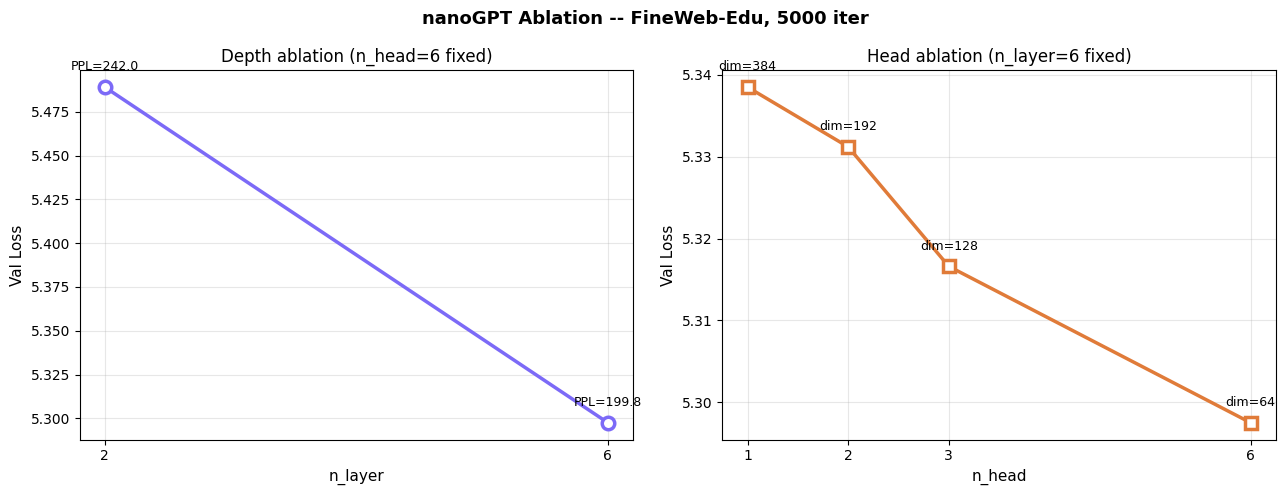

Saved: ablation/ablation_results.png


In [14]:
# Cell 10 -- Plot results
import json, numpy as np
import matplotlib.pyplot as plt

os.chdir("/kaggle/working")
with open("ablation/results.json") as f:
    results = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("nanoGPT Ablation -- FineWeb-Edu, 5000 iter", fontsize=13, fontweight="bold")

# Depth
depth = sorted([r for r in results if r["n_head"] == 6], key=lambda r: r["n_layer"])
if depth:
    ax = axes[0]
    ax.plot([r["n_layer"] for r in depth],
            [r["best_val"] for r in depth],
            "o-", color="#7c6af7", linewidth=2.5, markersize=9,
            markerfacecolor="white", markeredgewidth=2.5)
    for r in depth:
        ax.annotate(f"PPL={r['perplexity']:.1f}",
                    (r["n_layer"], r["best_val"]),
                    textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9)
    ax.set_xlabel("n_layer", fontsize=11)
    ax.set_ylabel("Val Loss", fontsize=11)
    ax.set_title("Depth ablation (n_head=6 fixed)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks([r["n_layer"] for r in depth])

# Heads
heads = sorted([r for r in results if r["n_layer"] == 6], key=lambda r: r["n_head"])
if heads:
    ax = axes[1]
    ax.plot([r["n_head"] for r in heads],
            [r["best_val"] for r in heads],
            "s-", color="#e07b39", linewidth=2.5, markersize=9,
            markerfacecolor="white", markeredgewidth=2.5)
    for r in heads:
        head_dim = 384 // r["n_head"]
        ax.annotate(f"dim={head_dim}",
                    (r["n_head"], r["best_val"]),
                    textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9)
    ax.set_xlabel("n_head", fontsize=11)
    ax.set_ylabel("Val Loss", fontsize=11)
    ax.set_title("Head ablation (n_layer=6 fixed)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks([r["n_head"] for r in heads])

plt.tight_layout()
plt.savefig("ablation/ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation/ablation_results.png")


In [15]:
# Cell 11 -- Save outputs (Kaggle auto-saves /kaggle/working/)
# All files in /kaggle/working/ are available as output after the run.
# Download via: notebook page -> Output -> Download

import os, json

print("Output files:")
for root, dirs, files in os.walk("/kaggle/working"):
    dirs[:] = [d for d in dirs if d not in ["__pycache__"]]
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path) / 1e3
        rel  = path.replace("/kaggle/working/", "")
        if not rel.startswith("data/train") and not rel.startswith("data/val"):
            print(f"  {rel:50s} {size:8.1f} KB")


Output files:
  model.py                                                9.8 KB
  train.py                                                9.1 KB
  generate.py                                             1.7 KB
  checkpoints/L2_H6/log.json                              1.3 KB
  checkpoints/L2_H6/ckpt.pt                          276131.2 KB
  checkpoints/L2_H6/config.json                           0.4 KB
  checkpoints/L6_H1/log.json                              1.3 KB
  checkpoints/L6_H1/ckpt.pt                          362403.4 KB
  checkpoints/L6_H1/config.json                           0.4 KB
  checkpoints/L6_H3/log.json                              1.3 KB
  checkpoints/L6_H3/ckpt.pt                          362403.4 KB
  checkpoints/L6_H3/config.json                           0.4 KB
  checkpoints/L6_H2/log.json                              1.3 KB
  checkpoints/L6_H2/ckpt.pt                          362403.4 KB
  checkpoints/L6_H2/config.json                           0.4 KB
  checkpoin

In [1]:
# Cell 12 (optional) -- Generate text from best model
import json, os
os.chdir("/kaggle/working")

with open("ablation/results.json") as f:
    results = json.load(f)

best = min(results, key=lambda r: r["best_val"])
run  = best["run"]
ckpt = f"checkpoints/{run}/ckpt.pt"
print(f"Best model: {run}  PPL={best['perplexity']:.2f}")

!python generate.py --checkpoint={ckpt} --prompt="Neural Network" --max_tokens=150 --num_samples=2


FileNotFoundError: [Errno 2] No such file or directory: 'ablation/results.json'